In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from plot_tmi_results import compute_tmi_from_singular_values
import os
import h5py
import csv
from scipy import stats
from FSS.DataCollapse import *

In [2]:
def read_tmi_results_to_df(p_fixed, p_fixed_name, p_c, L_values, n=0, threshold=1e-10):
    """
    Read singular values from HDF5 files, compute TMI statistics, and return results as a DataFrame.
    If results were previously computed and saved to CSV, read directly from CSV instead.
    
    Parameters:
    -----------
    p_fixed : float
        Fixed parameter value
    p_fixed_name : str
        Name of fixed parameter ('pproj' or 'pctrl')
    p_c : float
        Critical point value
    L_values : list
        List of L values to process
    n : int, optional
        Parameter for TMI computation
    threshold : float, optional
        Threshold for TMI computation
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with MultiIndex (p, L) containing TMI observations
    """
    output_filename = f'tmi_results_fine_{p_fixed_name}{p_fixed:.3f}_pc{p_c:.3f}.csv'
    p_scan_name = 'pctrl' if p_fixed_name == 'pproj' else 'pproj'
    # If CSV exists, read directly from it
    if os.path.exists(output_filename):
        print(f"Reading existing results from {output_filename}")
        data_list = []
        with open(output_filename, mode='r') as file:
            reader = csv.DictReader(file)
            for row in reader:
                data_list.append({
                    'p': float(row[f'{p_scan_name}_value']),
                    'L': int(row['L']),
                    'observations': float(row['tmi_value'])
                })
    else:
        data_list = []
        
        # Write results to CSV and collect data for DataFrame
        with open(output_filename, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(['L', p_fixed_name, p_scan_name + '_index', p_scan_name + '_value', 'sample_idx', 'tmi_value'])
            
            for L in L_values:
                filename = f'tmi_fine_L{L}_{p_fixed_name}{p_fixed:.3f}_pc{p_c}/final_results_L{L}.h5'
                if not os.path.exists(filename):
                    print(f"Warning: File {filename} not found!")
                    continue
                    
                print(f"\nAnalyzing file: {filename}")
                with h5py.File(filename, 'r') as f:
                    p_fixed_key = f"{p_fixed_name}{p_fixed:.3f}"
                    p_fixed_group = f[p_fixed_key]
                    p_scan_values = p_fixed_group[p_scan_name][:]
                    sv_group = p_fixed_group['singular_values']
                    
                    num_p_scan = len(p_fixed_group[p_scan_name])
                    
                    for p_scan_idx in range(num_p_scan):
                        num_samples = sv_group[list(sv_group.keys())[0]].shape[1]
                        singular_values = [{
                            key: sv_group[key][p_scan_idx, sample_idx] 
                            for key in sv_group.keys()
                        } for sample_idx in range(num_samples)]
                        
                        # Compute TMI for each sample
                        tmi_values = [compute_tmi_from_singular_values(sv, n, threshold) 
                                    for sv in singular_values]
                        
                        # Write to CSV and collect for DataFrame
                        for sample_idx, tmi_value in enumerate(tmi_values):
                            writer.writerow([L, p_fixed_key, p_scan_idx, p_scan_values[p_scan_idx], sample_idx, tmi_value])
                            data_list.append({
                                'p': p_scan_values[p_scan_idx],
                                'L': L,
                                'observations': tmi_value
                            })
    
    # Create DataFrame and group observations
    df = pd.DataFrame(data_list)
    df_grouped = df.groupby(['p', 'L'])['observations'].apply(list).reset_index()
    df_final = df_grouped.set_index(['p', 'L'])
    
    return df_final

In [25]:
p_fixed = 0.607
p_c = 0.480
df = read_tmi_results_to_df(p_fixed, p_fixed_name = 'pproj', p_c = p_c, L_values = [8, 12, 16, 20])
dc=DataCollapse(df, p_='p',L_='L',params={},p_range=[p_c - 0.1,p_c + 0.1],Lmin=12)
dc.datacollapse(p_c=p_c,nu=1,beta=0.,p_c_vary=True,beta_vary=True,nu_vary=True)

Reading existing results from tmi_results_fine_pproj0.607_pc0.480.csv


/Users/youtao/miniconda3/envs/scicomp/lib/python3.12/site-packages/lmfit/printfuncs.py:393: RuntimeWarning: divide by zero encountered in scalar divide
  spercent = f'({abs(par.stderr/par.value):.2%})'


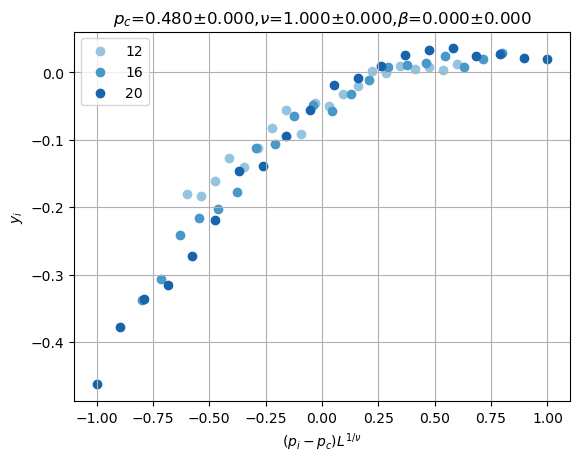

In [26]:
dc.plot_data_collapse()

In [14]:
df_ = df.applymap(np.mean)
df_std = df.applymap(lambda x: np.std(x)/np.sqrt(len(x)))

/var/folders/kg/tvbzq59s75x2mgxmldyjkcjw0000gn/T/ipykernel_73927/2234924016.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_ = df.applymap(np.mean)
/var/folders/kg/tvbzq59s75x2mgxmldyjkcjw0000gn/T/ipykernel_73927/2234924016.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_std = df.applymap(lambda x: np.std(x)/np.sqrt(len(x)))


In [ ]:
df

In [19]:
df_.index.get_level_values('p').unique()

Index([               0.43, 0.43526315789473685, 0.44052631578947365,
        0.4457894736842105, 0.45105263157894737, 0.45631578947368423,
       0.46157894736842103,  0.4668421052631579, 0.47210526315789475,
        0.4773684210526316,  0.4826315789473684, 0.48789473684210527,
       0.49315789473684213,   0.498421052631579,  0.5036842105263158,
        0.5089473684210526,  0.5142105263157895,  0.5194736842105263,
        0.5247368421052632,                0.53],
      dtype='float64', name='p')

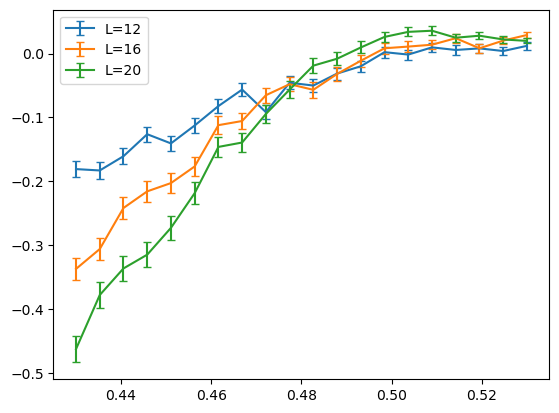

In [24]:
L=8
fig,ax=plt.subplots()
for L in [12,16,20]:
    ax.errorbar(df_.index.get_level_values('p').unique(),df_['observations'].xs(L,level='L'),yerr=df_std['observations'].xs(L,level='L'),label=f'L={L}',capsize=3)
    
ax.legend()

In [ ]:
# try larger sample size
# dense p scan resolutions close to pc
# try different threshold -- as related to pc and nu